# Attention Analysis Notebook

## Set Up from Previous

In [1]:
from torch.utils.data import DataLoader, TensorDataset, random_split
from gensim.models    import Word2Vec
import torch.nn.functional as F
import torch.nn as nn
import torch

import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
from tqdm import tqdm
from evaluation import all_metrics

import math
import json
import os
import copy
import pandas as pd    # NEW – to store experiment results
import time             # NEW – to track runtime for each config
from typing import Optional

# Optional: to ensure reproducibility
torch.manual_seed(42)

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [2]:
# Load Data

def load_data(split: str) -> DataLoader:
    """
    Load preprocessed tensor data for a given split.

    Args:
        split (str): One of {'train', 'val', 'test'}.

    Returns:
        DataLoader: A DataLoader wrapping the corresponding dataset.
    """
    X_data = torch.load(os.path.join("..", "Data", f"X_{split}.pt"))
    Y_data = torch.load(os.path.join("..", "Data", f"Y_{split}.pt"))

    return DataLoader(
        TensorDataset(X_data, Y_data),
        batch_size=32,
        shuffle=False,
        pin_memory=True
    )

In [3]:
# Model Architecture

class ConvAttnPool(nn.Module):
    """
    Convolution + Attention Pooling model using a pretrained Word2Vec embedding table.

    Args:
        table_path (str): Path to the pretrained Word2Vec model (.w2v file).
        label_space (int): Number of output labels/classes.
        num_of_filters (int): Number of convolutional filters.
        kernel_size (int): Kernel size for the Conv1d layer.
        drop_out (float): Dropout probability.

    Attributes:
        embed (nn.Embedding): Embedding layer initialized from pretrained vectors.
        conv (nn.Conv1d): Convolutional feature extractor.
        U (nn.Linear): Linear layer for attention projection.
        final (nn.Linear): Linear layer for classification weights.
        embed_drop (nn.Dropout): Dropout applied after embeddings.
    """

    def __init__(self, table_path: str, label_space: int = 50, num_of_filters: int = 10, kernel_size: int = 3, drop_out: float = 0.2):
        super().__init__()

        # Load pretrained Word2Vec model
        model = Word2Vec.load(table_path)
        vocab_size, embed_d = model.wv.vectors.shape

        # Prepare embedding table (append a zero vector for padding index)
        embed_table = torch.from_numpy(model.wv.vectors).float()
        embed_table = torch.cat([embed_table, torch.zeros((1, embed_d))], dim=0)

        # Embedding layer
        self.embed = nn.Embedding.from_pretrained(embeddings=embed_table, padding_idx=vocab_size)
        self.embed_drop = nn.Dropout(p=drop_out)

        # Convolutional feature extractor
        self.conv = nn.Conv1d(
            in_channels=embed_d,
            out_channels=num_of_filters,
            kernel_size=kernel_size,
            padding=kernel_size // 2
        )

        # Attention and output layers
        self.U = nn.Linear(num_of_filters, label_space)
        self.final = nn.Linear(num_of_filters, label_space)

        # Store embedding dimension for reference
        self.embedding_size = embed_d

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Forward pass.

        Args:
            x (torch.Tensor): Input tensor of token indices with shape (batch_size, seq_len).

        Returns:
            tuple:
                y (torch.Tensor): Logits for each label (batch_size, label_space).
                alpha (torch.Tensor): Attention weights (batch_size, label_space, seq_len).
        """
        x = self.embed(x)                # (B, L, embed_d)
        x = self.embed_drop(x)
        x = x.transpose(1, 2)            # (B, embed_d, L)
        x = torch.tanh(self.conv(x).transpose(1, 2))  # (B, L, num_of_filters)

        alpha = F.softmax(self.U.weight.matmul(x.transpose(1, 2)), dim=2)  # (B, label_space, L)
        m = alpha.matmul(x)             # (B, label_space, num_of_filters)
        y = self.final.weight.mul(m).sum(dim=2).add(self.final.bias)       # (B, label_space)

        return y, alpha

In [4]:
# Model Factory

def GenerateModel(table_path: str, num_of_filters: int = 15, kernel_size: int = 5) -> ConvAttnPool:
    """
    Factory function to create a ConvAttnPool model with standard hyperparameters.

    Args:
        table_path (str): Path to the pretrained Word2Vec model.
        num_of_filters (int): Number of convolutional filters.
        kernel_size (int): Kernel size for Conv1d.

    Returns:
        ConvAttnPool: Initialized model instance.
    """
    return ConvAttnPool(
        table_path=table_path,
        drop_out=0.2,
        num_of_filters=num_of_filters,
        label_space=50,
        kernel_size=kernel_size
    )


In [5]:
config = {
    "batch_size": 32,
    "lr": 0.002,
    "n_filters": 21,
    "window_size": 6,
    # the rest of the keys aren't used in the attention notebook
}

model_param_path = os.path.join("..", "Model", "processed_full.w2v")

### Recover Tokens from Input Sequences

In [6]:
from gensim.models import Word2Vec

# Load your W2V model to get the mapping index → token
w2v = Word2Vec.load(model_param_path)
idx_to_token = w2v.wv.index_to_key   # list where index maps to actual word

PAD_INDEX = len(idx_to_token)  # from ConvAttnPool padding_idx


In [7]:
# Load Trained Models and Test Data

# Paths to the saved models (update if your filenames differ)
MODEL_PATHS = {
    "Centralized": "../History/models/central_best_attention.pt",
    "FedAvg":      "../History/models/fedavg_c2e3_best_attention.pt",
    "FedProx":     "../History/models/fedprox_c2e3_best_attention.pt",
    "SCAFFOLD":    "../History/models/scaffold_c2e3_best_attention.pt",
}

def load_model(path):
    model = GenerateModel(
        table_path=model_param_path,
        num_of_filters=config["n_filters"],
        kernel_size=config["window_size"],
    ).to(device)
    state = torch.load(path, map_location=device)
    model.load_state_dict(state)
    model.eval()
    return model

# Load all four models
models = {name: load_model(p) for name, p in MODEL_PATHS.items()}
print("Loaded models:", list(models.keys()))

# Load test set
X_test = torch.load(os.path.join("..", "Data", "X_test.pt"))
Y_test = torch.load(os.path.join("..", "Data", "Y_test.pt"))
test_dataset = TensorDataset(X_test, Y_test)
print("Test samples:", len(test_dataset))


Loaded models: ['Centralized', 'FedAvg', 'FedProx', 'SCAFFOLD']
Test samples: 1729


### Get Per-Label Thresholds (needed for for converting logits -> predictions)

In [8]:
# Tune to find best threshold per label

@torch.no_grad()
def find_best_thresholds_per_label(model: nn.Module, data_loader: DataLoader, device: torch.device):
    """
    Finds an optimal sigmoid threshold per label to maximize F1 for each label independently.

    Returns:
        tuple:
            - macro_f1 (float): Average of best per-label F1s
            - thresholds (Tensor): Shape (num_labels,) with best threshold per label
    """
    model.eval()
    all_pred_raw, all_labels = [], []
    for X_batch, y_batch in data_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        preds, _ = model(X_batch)
        all_pred_raw.append(preds)
        all_labels.append(y_batch)

    all_pred_raw = torch.cat(all_pred_raw)
    all_labels = torch.cat(all_labels)
    sigm = torch.sigmoid(all_pred_raw)

    n_labels = all_labels.shape[1]
    best_thresholds = torch.zeros(n_labels, device=device)
    best_f1s = torch.zeros(n_labels, device=device)

    for i in range(n_labels):
        best_f, best_t = 0.0, 0.3
        for t in torch.arange(0.05, 0.95, 0.05):
            preds_i = (sigm[:, i] >= t).long()
            y_i = all_labels[:, i].long()
            tp = (preds_i * y_i).sum().item()
            fp = (preds_i * (1 - y_i)).sum().item()
            fn = ((1 - preds_i) * y_i).sum().item()
            prec = tp / (tp + fp + 1e-9)
            rec = tp / (tp + fn + 1e-9)
            f1 = 2 * prec * rec / (prec + rec + 1e-9)
            if f1 > best_f:
                best_f, best_t = f1, t
        best_thresholds[i] = best_t
        best_f1s[i] = best_f

    macro_f1 = best_f1s.mean().item()
    print(f"[Per-Label Thresholds] Macro F1={macro_f1:.4f}")
    return macro_f1, best_thresholds.cpu()

In [9]:
# Compute per-label thresholds for each attention model (stored in memory)
val_loader = load_data("val")

per_label_thr_by_model = {}
for model_name, model in models.items():
    _, thr = find_best_thresholds_per_label(model, val_loader, device)
    per_label_thr_by_model[model_name] = thr  # CPU tensor shape (C,)

print("Threshold vectors computed for:", list(per_label_thr_by_model.keys()))
print("Example thresholds (first 10) for Centralized:", per_label_thr_by_model["Centralized"][:10])

[Per-Label Thresholds] Macro F1=0.5834
[Per-Label Thresholds] Macro F1=0.5650
[Per-Label Thresholds] Macro F1=0.5635
[Per-Label Thresholds] Macro F1=0.5553
Threshold vectors computed for: ['Centralized', 'FedAvg', 'FedProx', 'SCAFFOLD']
Example thresholds (first 10) for Centralized: tensor([0.9000, 0.9000, 0.8000, 0.8000, 0.7000, 0.8000, 0.7500, 0.7500, 0.5000,
        0.7000])


## Choose Labels and Gather Shared Positive Samples

In [10]:
def collect_positive_samples_for_labels(dataset, label_indices, n_per_label=5):
    label_indices = list(label_indices)
    idx_by_label = {lbl: [] for lbl in label_indices}

    for i, (_, y) in enumerate(dataset):
        y = y.long()
        for lbl in label_indices:
            if y[lbl] == 1 and len(idx_by_label[lbl]) < n_per_label:
                idx_by_label[lbl].append(i)
        if all(len(v) >= n_per_label for v in idx_by_label.values()):
            break

    return idx_by_label

def build_batch_from_indices(dataset, indices):
    X_list, Y_list = [], []
    for idx in indices:
        x, y = dataset[idx]
        X_list.append(x)
        Y_list.append(y)
    return torch.stack(X_list), torch.stack(Y_list)

# pick some label indices you care about
label_indices = [3, 7]     # example; change to interesting labels
N_PER_LABEL   = 200        # <-- average over many positives (raise/lower as needed)

sample_indices_by_label = collect_positive_samples_for_labels(
    test_dataset, label_indices, n_per_label=N_PER_LABEL
)
sample_indices_by_label


{3: [17,
  29,
  38,
  55,
  69,
  88,
  102,
  112,
  117,
  140,
  145,
  166,
  167,
  171,
  188,
  192,
  200,
  207,
  209,
  214,
  215,
  225,
  236,
  262,
  264,
  270,
  300,
  303,
  306,
  310,
  311,
  325,
  333,
  334,
  335,
  342,
  343,
  360,
  367,
  387,
  396,
  446,
  464,
  498,
  509,
  517,
  537,
  565,
  573,
  577,
  584,
  585,
  593,
  599,
  604,
  605,
  624,
  633,
  672,
  687,
  696,
  702,
  715,
  727,
  731,
  732,
  736,
  738,
  751,
  754,
  755,
  762,
  765,
  784,
  790,
  819,
  827,
  849,
  852,
  859,
  866,
  895,
  902,
  909,
  914,
  919,
  940,
  946,
  947,
  963,
  969,
  989,
  1006,
  1014,
  1042,
  1075,
  1082,
  1093,
  1102,
  1103,
  1108,
  1133,
  1136,
  1156,
  1161,
  1170,
  1175,
  1176,
  1180,
  1186,
  1189,
  1202,
  1203,
  1225,
  1241,
  1242,
  1243,
  1244,
  1272,
  1276,
  1306,
  1314,
  1327,
  1353,
  1356,
  1359,
  1383,
  1386,
  1401,
  1421,
  1423,
  1449,
  1469,
  1474,
  1484,
  1497,
  1525,

## Extract Attention for All Models and Labels

In [11]:
@torch.no_grad()
def get_attention_for_label(model, X_batch, label_idx):
    X_batch = X_batch.to(device)
    logits, alpha = model(X_batch)  # alpha: (B, label_space, seq_len)
    # attention for this label only
    alpha_label = alpha[:, label_idx, :].cpu()   # (B, seq_len)
    logits_label = logits[:, label_idx].cpu()
    return logits_label, alpha_label                                      

    #one attention vector per sample (even if the sample doesnt predict the label) and one logit per sample
    #logits.shape = (B,C) where C = number of labels (50) and logits[b,l] is models raw score that label l applies to sample b
    #alpha[b,l,:] is how important token at posiiton i when predictiing l for sample b

attention_results = {}  # {model_name: {label_idx: {indices, logits, alpha}}}

for model_name, model in models.items():
    attention_results[model_name] = {}
    for lbl in label_indices:
        idxs = sample_indices_by_label[lbl]
        X_batch, Y_batch = build_batch_from_indices(test_dataset, idxs)
        logits_lbl, alpha_lbl = get_attention_for_label(model, X_batch, lbl)
        attention_results[model_name][lbl] = {
            "indices": idxs,
            "logits": logits_lbl,
            "alpha": alpha_lbl,   # shape (B, seq_len) where B = N_PER_LABEL and L = sequence length (fixed, padded)
        }

# quick sanity check
for m in attention_results:
    for lbl in attention_results[m]:
        print(m, "label", lbl, "alpha shape:",
              attention_results[m][lbl]["alpha"].shape)


Centralized label 3 alpha shape: torch.Size([155, 2501])
Centralized label 7 alpha shape: torch.Size([200, 2501])
FedAvg label 3 alpha shape: torch.Size([155, 2501])
FedAvg label 7 alpha shape: torch.Size([200, 2501])
FedProx label 3 alpha shape: torch.Size([155, 2501])
FedProx label 7 alpha shape: torch.Size([200, 2501])
SCAFFOLD label 3 alpha shape: torch.Size([155, 2501])
SCAFFOLD label 7 alpha shape: torch.Size([200, 2501])


## Quantative

###  Simple attention visualization (position heatmaps)

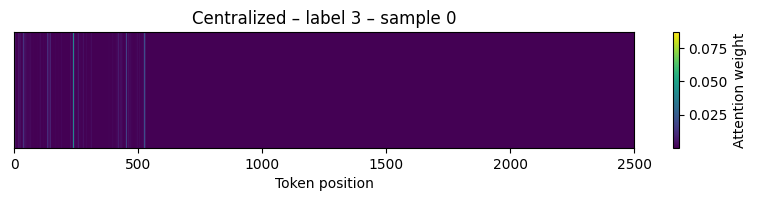

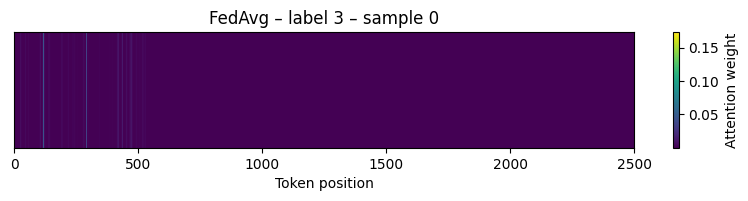

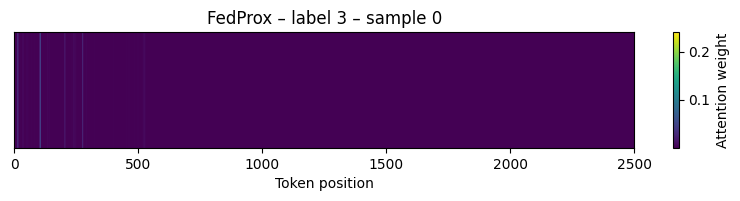

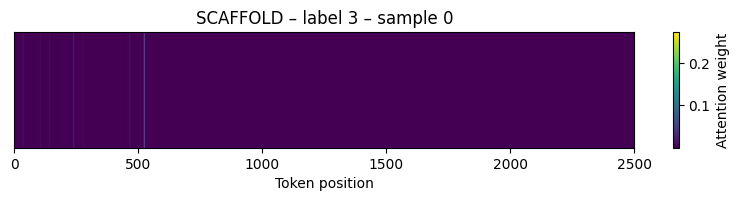

In [12]:
def plot_attention_heatmap(alpha_vec, title=""):
    plt.figure(figsize=(10, 1.5))
    plt.imshow(alpha_vec.unsqueeze(0).numpy(), aspect="auto")
    plt.colorbar(label="Attention weight")
    plt.yticks([])
    plt.xlabel("Token position")
    plt.title(title)
    plt.show()

# Example: first sample for first label, across all models
target_label = label_indices[0]
sample_in_batch = 0

for model_name in models.keys():
    alpha_batch = attention_results[model_name][target_label]["alpha"]
    alpha_vec = alpha_batch[sample_in_batch]  # (seq_len,)
    plot_attention_heatmap(
        alpha_vec,
        title=f"{model_name} – label {target_label} – sample {sample_in_batch}",
    )


### Similarity Metrics Between Models

In [13]:
def cosine_sim(a, b):
    # a, b: (seq_len,)
    return F.cosine_similarity(a.unsqueeze(0), b.unsqueeze(0)).item()

model_names = list(models.keys())

for lbl in label_indices:
    print(f"\n=== Label {lbl} ===")
    idx0 = sample_indices_by_label[lbl][0]
    X_batch, _ = build_batch_from_indices(test_dataset, [idx0])

    # collect one attention vector per model
    alpha_single = {}
    for name, model in models.items():
        _, alpha_lbl = get_attention_for_label(model, X_batch, lbl)
        alpha_single[name] = alpha_lbl[0]  # (seq_len,)

    # build similarity matrix
    sims = np.zeros((len(model_names), len(model_names)))
    for i, name_i in enumerate(model_names):
        for j, name_j in enumerate(model_names):
            sims[i, j] = cosine_sim(alpha_single[name_i], alpha_single[name_j])

    sim_df = pd.DataFrame(sims, index=model_names, columns=model_names)
    print(f"Cosine similarity of attention vectors for label {lbl}, sample idx {idx0}:")
    display(sim_df)



=== Label 3 ===
Cosine similarity of attention vectors for label 3, sample idx 17:


,Centralized,FedAvg,FedProx,SCAFFOLD
Centralized,1.000001,0.067476,0.106532,0.124547
FedAvg,0.067476,1.000000,0.090329,0.035203
FedProx,0.106532,0.090329,1.000000,0.084523
SCAFFOLD,0.124547,0.035203,0.084523,1.000007



=== Label 7 ===
Cosine similarity of attention vectors for label 7, sample idx 12:


,Centralized,FedAvg,FedProx,SCAFFOLD
Centralized,1.000005,0.889308,0.268025,0.496890
FedAvg,0.889308,1.000010,0.054852,0.119955
FedProx,0.268025,0.054852,1.000000,0.444769
SCAFFOLD,0.496890,0.119955,0.444769,1.000008


In [14]:
# --- Jaccard similarity helpers (PAD + context-window trimming) ---

def get_nonpad_len(x_1d: torch.Tensor, pad_index: int) -> int:
    """
    Returns number of non-PAD tokens assuming PAD fills from the end.
    """
    x = x_1d.detach().cpu()
    pad_pos = (x == pad_index).nonzero(as_tuple=False)
    return int(pad_pos[0].item()) if len(pad_pos) > 0 else int(x.numel())

def get_valid_positions(x_1d: torch.Tensor, pad_index: int, window_size: Optional[int]) -> np.ndarray:
    """
    Valid attention positions:
      - exclude PAD region
      - optionally trim 'half window' tokens at both ends to reduce conv padding artifacts
    """
    L = get_nonpad_len(x_1d, pad_index)
    if L <= 0:
        return np.array([], dtype=int)

    left, right = 0, L  # right is exclusive
    if window_size is not None and window_size > 1:
        half = window_size // 2
        left = min(left + half, L)
        right = max(right - half, left)

    return np.arange(left, right, dtype=int)

def topk_positions(att_vec_1d: torch.Tensor, valid_pos: np.ndarray, k: int) -> set[int]:
    """
    Return set of token positions corresponding to top-k attention weights within valid_pos.
    """
    if valid_pos.size == 0:
        return set()

    att = att_vec_1d.detach().cpu().numpy()
    att_valid = att[valid_pos]
    if att_valid.size == 0:
        return set()

    k_eff = min(k, att_valid.size)
    idx_part = np.argpartition(att_valid, -k_eff)[-k_eff:]
    idx_sorted = idx_part[np.argsort(att_valid[idx_part])[::-1]]

    return set(valid_pos[idx_sorted].tolist())

def jaccard(a: set[int], b: set[int]) -> float:
    if not a and not b:
        return 1.0
    if not a or not b:
        return 0.0
    return len(a & b) / len(a | b)


In [15]:
# --- Average Jaccard similarity across many positive samples (per label) ---

@torch.no_grad()
def attention_vec_for_label_single(model, x_1d, label_idx):
    """
    x_1d: (seq_len,)
    returns: attention vec (seq_len,)
    """
    _, alpha_lbl = get_attention_for_label(model, x_1d.unsqueeze(0), label_idx)
    return alpha_lbl[0]  # (seq_len,)

def avg_jaccard_matrix_for_label(
    dataset,
    sample_indices: list[int],
    label_idx: int,
    top_k: int = 15,
    trim_context_window: bool = True,
):
    model_names = list(models.keys())
    mat_vals = { (a,b): [] for a in model_names for b in model_names }

    window_size = config["window_size"] if trim_context_window else None

    for ds_idx in sample_indices:
        x, _ = dataset[ds_idx]
        valid_pos = get_valid_positions(x, PAD_INDEX, window_size)

        topk_by_model = {}
        for mname, m in models.items():
            att = attention_vec_for_label_single(m, x.to(device), label_idx)
            topk_by_model[mname] = topk_positions(att, valid_pos, k=top_k)

        for a in model_names:
            for b in model_names:
                mat_vals[(a,b)].append(jaccard(topk_by_model[a], topk_by_model[b]))

    # build dataframe
    M = np.zeros((len(model_names), len(model_names)), dtype=float)
    for i, a in enumerate(model_names):
        for j, b in enumerate(model_names):
            vals = mat_vals[(a,b)]
            M[i, j] = float(np.mean(vals)) if len(vals) else np.nan

    return pd.DataFrame(M, index=model_names, columns=model_names)

def mean_off_diagonal(df: pd.DataFrame) -> float:
    arr = df.values
    mask = ~np.eye(arr.shape[0], dtype=bool)
    return float(np.nanmean(arr[mask]))

TOP_K = 15
TRIM_CONTEXT = True  # set False to keep edge tokens

jaccard_results = {}
summary_rows = []

for lbl in label_indices:
    idxs = sample_indices_by_label[lbl]
    df_j = avg_jaccard_matrix_for_label(
        dataset=test_dataset,
        sample_indices=idxs,
        label_idx=lbl,
        top_k=TOP_K,
        trim_context_window=TRIM_CONTEXT,
    )
    jaccard_results[lbl] = df_j

    print(f"\nAvg Jaccard (top-{TOP_K}) | label={lbl} | n={len(idxs)} | trim_context={TRIM_CONTEXT}")
    display(df_j)

    summary_rows.append({
        "label": lbl,
        "n_samples": len(idxs),
        "top_k": TOP_K,
        "trim_context": TRIM_CONTEXT,
        "mean_pairwise_jaccard": mean_off_diagonal(df_j),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("mean_pairwise_jaccard", ascending=False)
print("\nSummary (mean off-diagonal Jaccard per label):")
display(summary_df)



Avg Jaccard (top-15) | label=3 | n=155 | trim_context=True


,Centralized,FedAvg,FedProx,SCAFFOLD
Centralized,1.000000,0.176980,0.186226,0.192994
FedAvg,0.176980,1.000000,0.143412,0.260368
FedProx,0.186226,0.143412,1.000000,0.161006
SCAFFOLD,0.192994,0.260368,0.161006,1.000000



Avg Jaccard (top-15) | label=7 | n=200 | trim_context=True


,Centralized,FedAvg,FedProx,SCAFFOLD
Centralized,1.000000,0.082761,0.096253,0.095213
FedAvg,0.082761,1.000000,0.049242,0.064946
FedProx,0.096253,0.049242,1.000000,0.065153
SCAFFOLD,0.095213,0.064946,0.065153,1.000000



Summary (mean off-diagonal Jaccard per label):


,label,n_samples,top_k,trim_context,mean_pairwise_jaccard
0,3,155,15,True,0.186831
1,7,200,15,True,0.075595


## Qualitative

### Decode a Sequence of Token IDs into Words

In [16]:
def decode_sequence(token_ids):
    tokens = []
    for idx in token_ids:
        idx = int(idx)
        if idx == PAD_INDEX:
            tokens.append("<PAD>")
        else:
            tokens.append(idx_to_token[idx])
    return tokens


### Visualize Attention By Token

In [17]:
def get_top_tokens(tokens, attention, k=15, skip_pad=True):
    """
    Return the top-k tokens by attention weight.
    tokens   : list[str]
    attention: 1D tensor of attention weights
    k        : how many tokens to return
    skip_pad : skip '<PAD>' tokens
    """
    att = attention.cpu().numpy()
    idxs = np.argsort(att)[::-1]  # highest first

    top = []
    for idx in idxs:
        tok = tokens[idx]
        if skip_pad and tok == "<PAD>":
            continue
        top.append((idx, tok, float(att[idx])))
        if len(top) >= k:
            break
    return top


In [18]:
from IPython.display import HTML

def attention_to_html(tokens, attention, max_color=240):
    att = attention / attention.max()
    html = ""
    for tok, w in zip(tokens, att):
        intensity = int(max_color * float(w))
        html += f"<span style='background-color: rgb(255,255,{255-intensity}); padding:2px; margin:1px;'>{tok}</span>"
    return HTML(html)

def show_attention(model_name, label_idx, sample_dataset_idx=0, top_k=15):
    # get the sample
    x, y = test_dataset[sample_dataset_idx]
    tokens = decode_sequence(x)

    # get attention weights for this model + label
    logits, alpha = get_attention_for_label(models[model_name], x.unsqueeze(0), label_idx)
    attention_vec = alpha[0]  # shape (seq_len,)

    print(f"\nModel: {model_name} | Label: {label_idx} | Sample index: {sample_dataset_idx}")
    display(attention_to_html(tokens, attention_vec))

    # print top-k tokens by attention
    top = get_top_tokens(tokens, attention_vec, k=top_k)
    print(f"Top {top_k} tokens by attention:")
    for pos, tok, w in top:
        print(f"  pos={pos:4d}  att={w:.4f}  token='{tok}'")


### Compare Qualitative Attention Across Models

In [19]:
target_label = 7          # change to any interesting label
sample_idx    = 123       # a test sample index

for model_name in models.keys():
    show_attention(model_name, target_label, sample_idx)



Model: Centralized | Label: 7 | Sample index: 123


Top 15 tokens by attention:
  pos= 310  att=0.0307  token='mg'
  pos=  20  att=0.0224  token='pain'
  pos= 561  att=0.0160  token='needed'
  pos= 350  att=0.0154  token='and'
  pos=  90  att=0.0141  token='pain'
  pos= 425  att=0.0135  token='admission'
  pos= 174  att=0.0133  token='dry'
  pos= 681  att=0.0131  token='cecal'
  pos= 123  att=0.0131  token='cecal'
  pos= 119  att=0.0129  token='ulcer'
  pos= 677  att=0.0129  token='ulcer'
  pos= 157  att=0.0116  token='b'
  pos= 339  att=0.0108  token='propofol'
  pos= 162  att=0.0106  token='weight'
  pos= 806  att=0.0100  token='down'

Model: FedAvg | Label: 7 | Sample index: 123


Top 15 tokens by attention:
  pos= 329  att=0.0465  token='note'
  pos= 173  att=0.0414  token='skin'
  pos= 358  att=0.0358  token='as'
  pos= 322  att=0.0357  token='room'
  pos= 398  att=0.0273  token='he'
  pos= 271  att=0.0238  token='wbc'
  pos= 166  att=0.0205  token='obese'
  pos= 259  att=0.0179  token='wbc'
  pos= 247  att=0.0167  token='wbc'
  pos= 310  att=0.0161  token='mg'
  pos= 822  att=0.0132  token='lifting'
  pos= 363  att=0.0132  token='brief'
  pos= 379  att=0.0131  token='mobility'
  pos= 168  att=0.0122  token='male'
  pos= 212  att=0.0097  token='warm'

Model: FedProx | Label: 7 | Sample index: 123


Top 15 tokens by attention:
  pos= 162  att=0.2666  token='weight'
  pos= 666  att=0.0709  token='discharge'
  pos= 325  att=0.0421  token='was'
  pos= 340  att=0.0177  token='he'
  pos= 329  att=0.0168  token='note'
  pos= 120  att=0.0154  token='h'
  pos= 678  att=0.0154  token='h'
  pos= 122  att=0.0115  token='bleeding'
  pos= 680  att=0.0115  token='bleeding'
  pos= 877  att=0.0104  token='with'
  pos= 657  att=0.0102  token='care'
  pos= 313  att=0.0095  token='course'
  pos= 175  att=0.0089  token='x'
  pos= 806  att=0.0085  token='down'
  pos= 337  att=0.0084  token='epinephrine'

Model: SCAFFOLD | Label: 7 | Sample index: 123


Top 15 tokens by attention:
  pos= 841  att=0.1060  token='office'
  pos= 902  att=0.1060  token='office'
  pos= 328  att=0.0283  token='operative'
  pos= 106  att=0.0243  token='this'
  pos= 107  att=0.0193  token='past'
  pos= 290  att=0.0164  token='creat'
  pos= 403  att=0.0147  token='rehab'
  pos= 811  att=0.0139  token='driving'
  pos= 807  att=0.0138  token='on'
  pos= 916  att=0.0120  token='person'
  pos= 855  att=0.0120  token='person'
  pos= 121  att=0.0119  token='o'
  pos= 679  att=0.0119  token='o'
  pos= 155  att=0.0117  token='o2'
  pos= 316  att=0.0110  token='he'


## Original 4 Questions

### 1. Do different models focus on the same tokens given the same input and prediction?

This helps us assess whether federated models preserve reasoning patterns similar to centralized training.

We compute agreement **only on samples where a pair of models makes the same prediction for the same label**.
Metrics:
- Cosine similarity between full attention vectors
- Top-k Jaccard overlap between attended token positions

We report per-label distributions (mean/median/IQR) and an overall summary

### 2. Are there cases where models make the same prediction but rely on different tokens?

These cases are particularly important, as they indicate potential differences in learned clinical rationale even when accuracy agrees.

### 3. How does attention agreement change across label frequency?

We are especially interested in whether agreement degrades for rare diagnoses compared to frequent ones.

### 4. Which federated methods behave closest to centralized training in terms of attention structure?

This allows us to compare federated methods beyond predictive performance and look at behavioral alignment.